# K-Means Clustering

## Overview

**K-Means** is the most widely used clustering algorithm. It partitions a dataset into $k$ groups by iteratively assigning samples to their nearest centroid and updating centroids as the mean of assigned samples. It is fast, scalable, and easy to interpret.

K-Means is an **unsupervised** algorithm — it finds structure in data without labels.

---

## Algorithm — Lloyd's Method

Given data $X \in \mathbb{R}^{n \times p}$ and a target number of clusters $k$:

**1. Initialize** $k$ centroids $\{\mu_1, \dots, \mu_k\}$.

**2. Assignment step** — assign each sample to the nearest centroid:
$$c_i = \arg\min_j \|\mathbf{x}_i - \mu_j\|^2$$

**3. Update step** — recompute each centroid as the mean of its cluster:
$$\mu_j = \frac{1}{|C_j|} \sum_{i \in C_j} \mathbf{x}_i$$

**4. Repeat** steps 2–3 until centroids change by less than tolerance $\epsilon$ or max iterations is reached.

---

## Objective Function

K-Means minimizes **within-cluster sum of squares (WCSS)**, also called **inertia**:

$$\mathcal{L} = \sum_{j=1}^{k} \sum_{i \in C_j} \|\mathbf{x}_i - \mu_j\|^2$$

This is a non-convex objective — the algorithm finds a local minimum. Multiple restarts (`n_init`) with the best solution selected by inertia mitigate this.

---

## Initialization — K-Means++

Poor initialization can lead to slow convergence or suboptimal clusters. **K-Means++** improves on random initialization by spreading centroids apart:

1. Choose the first centroid uniformly at random.
2. For each subsequent centroid, choose with probability proportional to $d(\mathbf{x}, \mathcal{C})^2$ — the squared distance to the nearest already-chosen centroid.

This gives an $O(\log k)$ approximation guarantee on the objective.

---

## Choosing K — The Elbow Method

K-Means requires specifying $k$ in advance. The **elbow method** plots inertia vs $k$:

- As $k$ increases, inertia decreases monotonically.
- The "elbow" — where the rate of decrease sharply slows — suggests the optimal $k$.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Partitional, centroid-based clustering |
| **Objective** | Minimize within-cluster sum of squares |
| **Convergence** | Guaranteed to converge, not necessarily to global optimum |
| **Complexity** | $O(n \cdot k \cdot d \cdot \text{iters})$ |
| **Limitation** | Assumes spherical clusters; sensitive to outliers and scale |

 EXPERIMENT 1 — K-Means on Synthetic Blobs


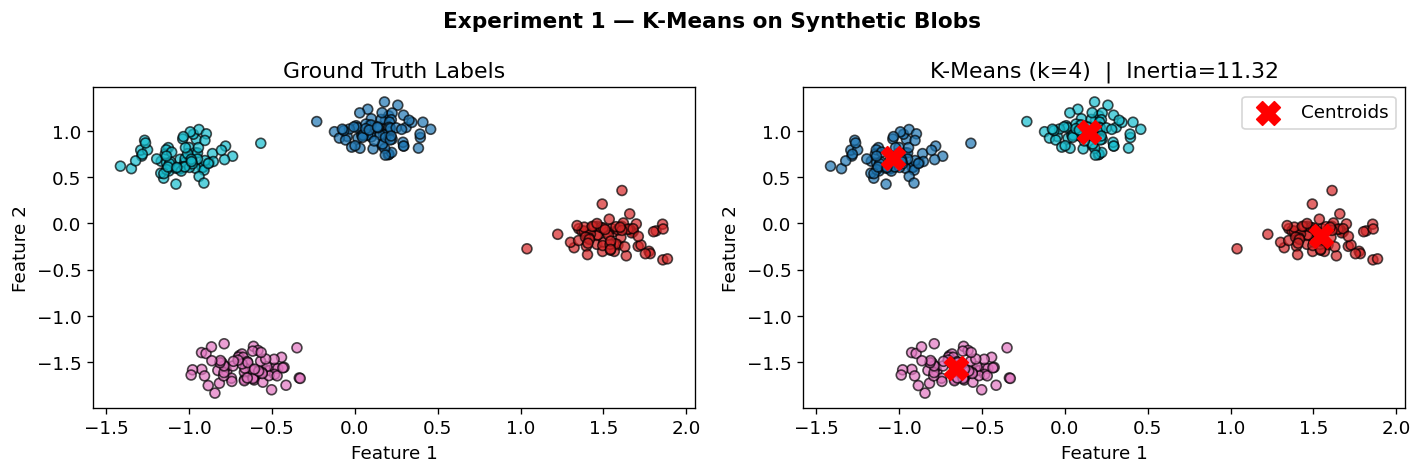

ARI  : 1.0000  (1.0 = perfect)
Inertia: 11.3170

 EXPERIMENT 2 — Elbow Method


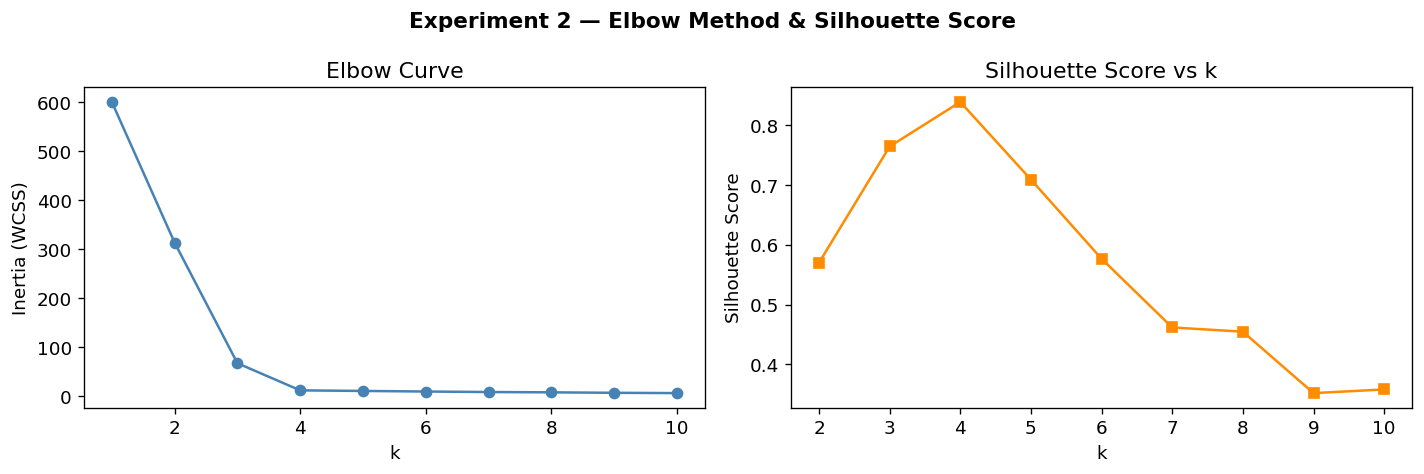

Best k by silhouette: 4

 EXPERIMENT 3 — KMeans++ vs Random Init


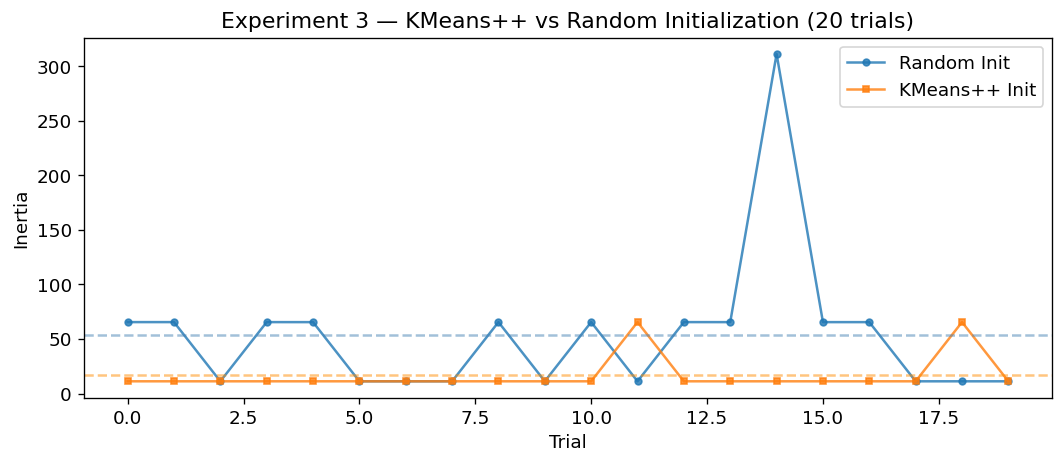

Random Init  — mean inertia: 53.4219
KMeans++ Init — mean inertia: 16.7398

 EXPERIMENT 4 — Iris Dataset


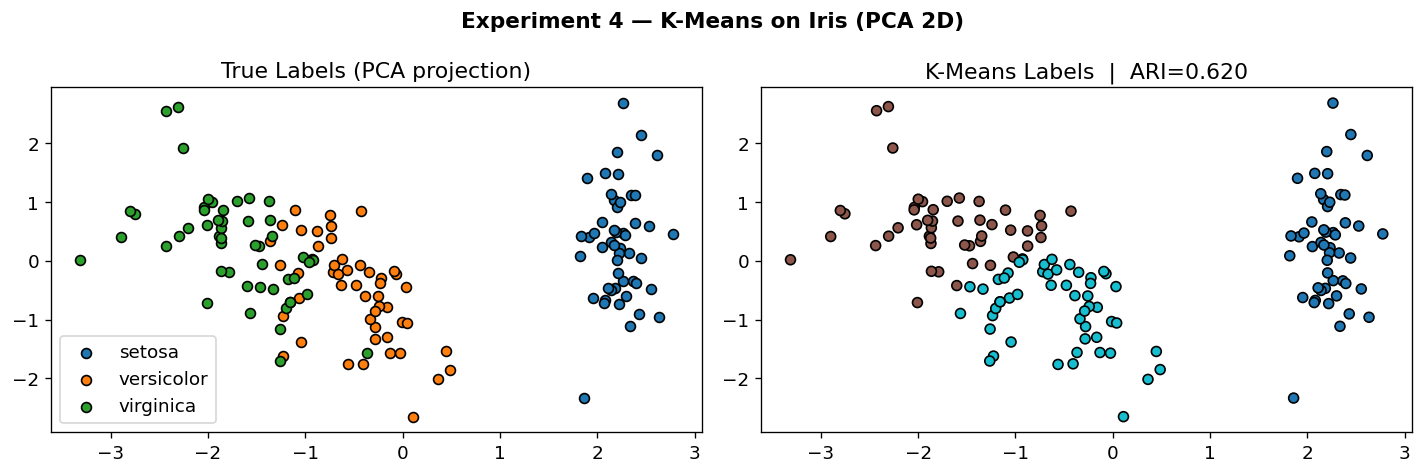

ARI  : 0.6201
Silhouette: 0.4599

 EXPERIMENT 5 — Limitation: Non-Spherical Data


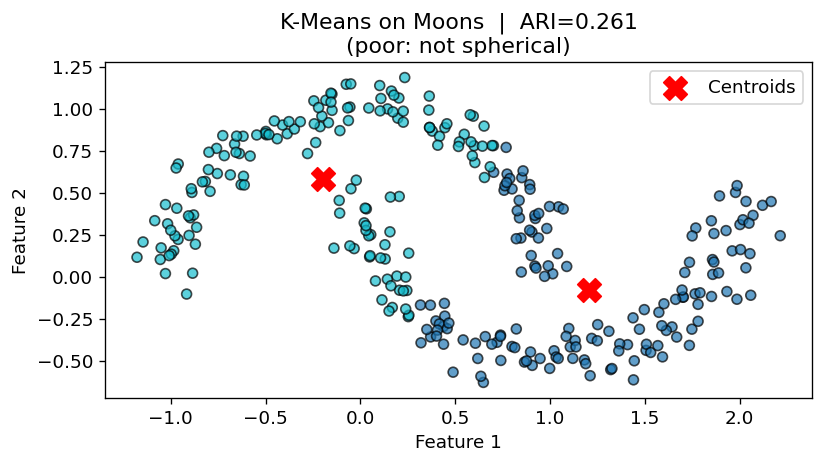

K-Means fails on moons — clusters are not convex/spherical.
DBSCAN handles this case correctly.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.unsupervised_learning.kmeans import KMeans

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_clusters(X, labels, centroids, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10",
               edgecolors="k", s=35, alpha=0.7)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c="red", marker="X", s=200, zorder=5, label="Centroids")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()


# ── 1. K-Means on Synthetic Blobs ────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — K-Means on Synthetic Blobs")
print("=" * 55)

X_blobs, y_true = make_blobs(n_samples=300, centers=4,
                              cluster_std=0.8, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

km = KMeans(k=4, random_state=42)
km.fit(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_true, cmap="tab10",
                edgecolors="k", s=35, alpha=0.7)
axes[0].set_title("Ground Truth Labels")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")
plot_clusters(X_blobs, km.labels_, km.centroids_, axes[1],
    f"K-Means (k=4)  |  Inertia={km.inertia_:.2f}")
plt.suptitle("Experiment 1 — K-Means on Synthetic Blobs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"ARI  : {adjusted_rand_score(y_true, km.labels_):.4f}  (1.0 = perfect)")
print(f"Inertia: {km.inertia_:.4f}\n")


# ── 2. Elbow Method — Choosing K ─────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Elbow Method")
print("=" * 55)

k_range = range(1, 11)
inertias, sil_scores = [], []
for k in k_range:
    km_k = KMeans(k=k, random_state=42)
    km_k.fit(X_blobs)
    inertias.append(km_k.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_blobs, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Curve")

axes[1].plot(range(2, 11), sil_scores, marker="s", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.suptitle("Experiment 2 — Elbow Method & Silhouette Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
best_k = range(2, 11)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}\n")


# ── 3. K-Means++ vs Random Initialization ────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — KMeans++ vs Random Init")
print("=" * 55)

n_trials = 20
inertias_random, inertias_pp = [], []
for seed in range(n_trials):
    km_r = KMeans(k=4, init="random",   n_init=1, random_state=seed)
    km_p = KMeans(k=4, init="kmeans++", n_init=1, random_state=seed)
    km_r.fit(X_blobs)
    km_p.fit(X_blobs)
    inertias_random.append(km_r.inertia_)
    inertias_pp.append(km_p.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(inertias_random, marker="o", markersize=4, label="Random Init",   alpha=0.8)
ax.plot(inertias_pp,     marker="s", markersize=4, label="KMeans++ Init", alpha=0.8)
ax.axhline(np.mean(inertias_random), linestyle="--", color="steelblue",   alpha=0.5)
ax.axhline(np.mean(inertias_pp),     linestyle="--", color="darkorange",  alpha=0.5)
ax.set_xlabel("Trial")
ax.set_ylabel("Inertia")
ax.set_title("Experiment 3 — KMeans++ vs Random Initialization (20 trials)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Random Init  — mean inertia: {np.mean(inertias_random):.4f}")
print(f"KMeans++ Init — mean inertia: {np.mean(inertias_pp):.4f}\n")


# ── 4. Real Dataset — Iris ────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Iris Dataset")
print("=" * 55)

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

km_iris = KMeans(k=3, random_state=42)
km_iris.fit(X_iris)

pca_for_vis = __import__("sys")
import importlib, sys
sys.path.insert(0, os.path.abspath("../../"))
from mlpackage.unsupervised_learning.pca import PCA

pca = PCA(n_components=2)
X_iris_2d = pca.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name in enumerate(iris.target_names):
    mask = iris.target == label
    axes[0].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1],
                    label=name, edgecolors="k", s=35)
axes[0].set_title("True Labels (PCA projection)")
axes[0].legend()

scatter = axes[1].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1],
                           c=km_iris.labels_, cmap="tab10",
                           edgecolors="k", s=35)
axes[1].set_title(f"K-Means Labels  |  ARI={adjusted_rand_score(iris.target, km_iris.labels_):.3f}")
plt.suptitle("Experiment 4 — K-Means on Iris (PCA 2D)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"ARI  : {adjusted_rand_score(iris.target, km_iris.labels_):.4f}")
print(f"Silhouette: {silhouette_score(X_iris, km_iris.labels_):.4f}\n")


# ── 5. Limitation — Non-Spherical Clusters ────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 5 — Limitation: Non-Spherical Data")
print("=" * 55)

X_moon, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
km_moon = KMeans(k=2, random_state=42)
km_moon.fit(X_moon)

fig, ax = plt.subplots(figsize=(7, 4))
plot_clusters(X_moon, km_moon.labels_, km_moon.centroids_, ax,
    f"K-Means on Moons  |  ARI={adjusted_rand_score(_, km_moon.labels_):.3f}\n(poor: not spherical)")
plt.tight_layout()
plt.show()
print("K-Means fails on moons — clusters are not convex/spherical.")
print("DBSCAN handles this case correctly.\n")